# Cross-Selling & Up-Selling via Embedding Similarity
## Electronics — Hybrid Embedding Demonstration
**Prerequisite:** Phase 1 & 2 of the recommender pipeline must have been run.  
**Inputs required:** `hybrid_item_embeddings.npy`, `full_item2idx.json`, `meta_electonics_Products.jsonl.gz`, `electronics.jsonl.gz`

---
> This notebook demonstrates that the 128-dimensional hybrid embeddings (behavioural + semantic) support meaningful cross-sell and up-sell retrieval using cosine similarity alone — **no retraining needed**.

### Step 1: Imports

In [1]:
import numpy as np
import json
import gzip
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict

print("Imports ready.")

Imports ready.


### Step 2: Load Hybrid Embeddings & Item Mappings

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

DRIVE_SAVE_DIR = '/content/drive/MyDrive/recommender_electronics'

# Load embeddings and mappings directly from Drive — no retraining needed
import shutil, os
files_needed = [
    'hybrid_item_embeddings.npy',
    'full_item2idx.json',
]
for fname in files_needed:
    src = os.path.join(DRIVE_SAVE_DIR, fname)
    dst = f'/content/{fname}'
    if not os.path.exists(dst):           # only copy if not already in runtime
        shutil.copy2(src, dst)
        print(f"  Loaded: {fname}")
    else:
        print(f"  Already present: {fname}")

elec_final_embs = np.load('hybrid_item_embeddings.npy')
with open('full_item2idx.json', 'r') as f:
    elec_full_item2idx = json.load(f)
elec_idx2item = {v: k for k, v in elec_full_item2idx.items()}

print(f"\nEmbeddings shape : {elec_final_embs.shape}")
print(f"Vocabulary size  : {len(elec_full_item2idx)}")

Mounted at /content/drive
  Loaded: hybrid_item_embeddings.npy
  Loaded: full_item2idx.json

Embeddings shape : (353, 128)
Vocabulary size  : 353


### Step 3: Load Metadata — Titles, Brands, Categories

In [3]:
# Electronics Reviews
!wget -q --show-progress https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/Electronics.jsonl.gz

# Electronics Metadata
!wget -q --show-progress https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/meta_categories/meta_Electronics.jsonl.gz

Electronics.jsonl.g 100%[===================>]   6.03G  16.3MB/s    in 7m 46s  
meta_Electronics.js 100%[===================>]   1.22G  7.64MB/s    in 5m 10s  


In [4]:
# Stream metadata from gzipped JSONL — RAM-safe
CHUNK_SIZE    = 50_000
relevant_cols = ['asin', 'parent_asin', 'title', 'description', 'brand', 'categories']

chunks, chunk = [], []
with gzip.open('meta_Electronics.jsonl.gz', 'rt', encoding='utf-8') as f:
    for i, line in enumerate(f):
        obj = json.loads(line)
        chunk.append({col: obj.get(col) for col in relevant_cols})
        if len(chunk) >= CHUNK_SIZE:
            chunks.append(pd.DataFrame(chunk))
            chunk = []
            print(f"  Loaded {i+1} rows...", end='\r')
    if chunk:
        chunks.append(pd.DataFrame(chunk))

meta_df = pd.concat(chunks, ignore_index=True)
del chunks, chunk

print(f"\nMetadata loaded: {len(meta_df)} rows")
print(f"Columns: {meta_df.columns.tolist()}")


Metadata loaded: 1610012 rows
Columns: ['asin', 'parent_asin', 'title', 'description', 'brand', 'categories']


### Step 4: Build Lookup Dictionaries — Titles & Categories

In [5]:
item_titles     = {}   # asin -> display title (str)
item_categories = {}   # asin -> primary category (str)

for _, row in meta_df.iterrows():
    asin        = row.get('asin') or ''
    parent_asin = row.get('parent_asin') or asin
    title       = str(row.get('title',  '') or '').strip()
    brand       = str(row.get('brand',  '') or '').strip()
    cats        = row.get('categories') or []
    # First non-empty category string becomes the primary category
    primary_cat = next(
        (c.strip() for c in cats if isinstance(c, str) and c.strip()),
        'Electronics'
    )
    display = title if title else (brand if brand else asin)

    for key in {asin, parent_asin} - {''}:
        item_titles[key]     = display[:80]
        item_categories[key] = primary_cat

print(f"Titles available     : {len(item_titles)}")
print(f"Categories available : {len(item_categories)}")
print(f"Unique categories    : {len(set(item_categories.values()))}")
print()
for k in list(item_titles.keys())[:3]:
    print(f"  {k} | {item_titles[k][:50]} | {item_categories.get(k, '—')}")

Titles available     : 1610012
Categories available : 1610012
Unique categories    : 3

  B00MCW7G9M | FS-1051 FATSHARK TELEPORTER V3 HEADSET | Electronics
  B00YT6XQSE | Ce-H22B12-S1 4Kx2K Hdmi 4Port | Electronics
  B07SM135LS | Digi-Tatoo Decal Skin Compatible With MacBook Pro  | Electronics


### Step 5: Build Ratings Lookup from Review Data

In [6]:
# Load reviews to compute per-item average ratings (rating metadata for up-sell)
MAX_REVIEW_ROWS = 100_000
review_chunks, chunk = [], []

with gzip.open('Electronics.jsonl.gz', 'rt', encoding='utf-8') as f:
    for i, line in enumerate(f):
        obj = json.loads(line)
        pa  = obj.get('parent_asin')
        rt  = obj.get('rating')
        if pa and rt is not None:
            chunk.append({'parent_asin': pa, 'rating': float(rt)})
        if i >= MAX_REVIEW_ROWS:
            break
        if len(chunk) >= 50_000:
            review_chunks.append(pd.DataFrame(chunk))
            chunk = []
    if chunk:
        review_chunks.append(pd.DataFrame(chunk))

reviews_df   = pd.concat(review_chunks, ignore_index=True)
del review_chunks, chunk

avg_ratings = reviews_df.groupby('parent_asin')['rating'].mean()
item_ratings = avg_ratings.to_dict()

print(f"Ratings loaded for {len(item_ratings)} items")
vals = list(item_ratings.values())
if vals:
    print(f"  Min: {min(vals):.2f}  Max: {max(vals):.2f}  Avg: {sum(vals)/len(vals):.2f} ★")

Ratings loaded for 59429 items
  Min: 1.00  Max: 5.00  Avg: 4.22 ★


### Step 6: Core Cosine Similarity Function
*(Efficient vectorised — no full N×N matrix)*

In [7]:
def cosine_similarity_single(query_vec: np.ndarray,
                              emb_matrix: np.ndarray) -> np.ndarray:
    """
    Compute cosine similarity between ONE query vector and ALL rows
    of emb_matrix using vectorised NumPy — O(N·D), not O(N²).

    Parameters
    ----------
    query_vec  : shape (D,)
    emb_matrix : shape (N, D)

    Returns
    -------
    similarities : shape (N,)  — one score per item
    """
    q_norm = query_vec / (np.linalg.norm(query_vec) + 1e-10)
    m_norm = emb_matrix / (np.linalg.norm(emb_matrix, axis=1, keepdims=True) + 1e-10)
    return m_norm @ q_norm    # dot product of L2-normalised vectors = cosine sim


def get_query_embedding(item_id: str) -> tuple:
    """Retrieve (idx, embedding_vector) for item_id; (None, None) if missing."""
    idx = elec_full_item2idx.get(item_id)
    if idx is None:
        print(f"  [!] '{item_id}' not in vocabulary.")
        return None, None
    return idx, elec_final_embs[idx]


print("Similarity utilities defined.")

Similarity utilities defined.


### Step 7: Cross-Sell Retrieval Function

In [8]:
def cross_sell(item_id: str,
               k: int = 10,
               min_sim: float = 0.30) -> list:
    """
    Cross-Selling: retrieve top-K similar items.

    Strategy
    --------
    - If category info is available, prefer items from a DIFFERENT category
      (complementary products). Falls back to same-category if not enough
      cross-category results exceed min_sim.
    - If no category info is available, return any top-K similar items.

    Parameters
    ----------
    item_id  : ASIN of the query item
    k        : number of recommendations to return
    min_sim  : minimum cosine similarity threshold

    Returns
    -------
    List of dicts: item_id, title, category, similarity
    """
    query_idx, query_vec = get_query_embedding(item_id)
    if query_vec is None:
        return []

    query_cat = item_categories.get(item_id, '')
    sims      = cosine_similarity_single(query_vec, elec_final_embs)
    ranked    = np.argsort(sims)[::-1]     # descending

    results = []
    for idx in ranked:
        if int(idx) == query_idx:
            continue                        # skip self
        cand_id = elec_full_idx2item.get(int(idx), '')
        if cand_id in ('<PAD>', '<UNK>', ''):
            continue
        sim = float(sims[idx])
        if sim < min_sim:
            break                           # sorted — no need to continue
        cat = item_categories.get(cand_id, '')
        results.append({
            'item_id'   : cand_id,
            'title'     : item_titles.get(cand_id, '(no title)')[:70],
            'category'  : cat or 'Electronics',
            'similarity': round(sim, 4),
            '_cross'    : bool(query_cat and cat and cat != query_cat),
        })
        if len(results) >= k * 4:           # gather extra pool to re-rank
            break

    # Prefer cross-category; fill with same-category if needed
    cross = [r for r in results if r['_cross']]
    same  = [r for r in results if not r['_cross']]
    final = (cross + same)[:k]
    for r in final:
        del r['_cross']
    return final


print("cross_sell() defined.")

cross_sell() defined.


### Step 8: Up-Sell Retrieval Function

In [9]:
def up_sell(item_id: str,
            k: int = 10,
            min_sim: float = 0.30,
            min_rating_delta: float = 0.1) -> list:
    """
    Up-Selling: retrieve top-K similar items from the SAME category
    that have a higher average rating (premium alternatives).

    Strategy
    --------
    - Restrict candidates to the same category as the query item.
    - Prefer items with avg_rating > query_rating + min_rating_delta (upgrades).
    - If rating metadata is absent, fall back to pure similarity within same category.

    Parameters
    ----------
    item_id          : ASIN of the query item
    k                : number of recommendations to return
    min_sim          : minimum cosine similarity threshold
    min_rating_delta : minimum rating improvement to qualify as an upgrade

    Returns
    -------
    List of dicts: item_id, title, category, similarity, avg_rating, rating_gain
    """
    query_idx, query_vec = get_query_embedding(item_id)
    if query_vec is None:
        return []

    query_cat    = item_categories.get(item_id, '')
    query_rating = item_ratings.get(item_id, 0.0)
    sims         = cosine_similarity_single(query_vec, elec_final_embs)
    ranked       = np.argsort(sims)[::-1]

    upgrades, same_cat = [], []

    for idx in ranked:
        if int(idx) == query_idx:
            continue
        cand_id = elec_full_idx2item.get(int(idx), '')
        if cand_id in ('<PAD>', '<UNK>', ''):
            continue
        sim = float(sims[idx])
        if sim < min_sim:
            break

        cat    = item_categories.get(cand_id, '')
        rating = item_ratings.get(cand_id, 0.0)

        # Restrict to same category (or skip check when no category info exists)
        if query_cat and cat and cat != query_cat:
            continue

        entry = {
            'item_id'    : cand_id,
            'title'      : item_titles.get(cand_id, '(no title)')[:70],
            'category'   : cat or 'Electronics',
            'similarity' : round(sim, 4),
            'avg_rating' : round(rating, 2),
            'rating_gain': round(rating - query_rating, 2),
        }
        if rating >= query_rating + min_rating_delta:
            upgrades.append(entry)
        else:
            same_cat.append(entry)

        if len(upgrades) + len(same_cat) >= k * 4:
            break

    # Return genuine upgrades first, then same-category fill
    return (upgrades + same_cat)[:k]


print("up_sell() defined.")

up_sell() defined.


### Step 9: Unified `get_recommendations()` API

In [10]:
def get_recommendations(item_id: str,
                        mode: str = 'cross',
                        k: int = 10,
                        min_sim: float = 0.30,
                        min_rating_delta: float = 0.1) -> list:
    """
    Unified recommendation entry point.

    Parameters
    ----------
    item_id          : ASIN of the query item
    mode             : 'cross' → cross-sell (complementary, different category)
                       'up'    → up-sell    (premium, same category, higher rating)
    k                : number of results to return
    min_sim          : minimum cosine similarity (default 0.30)
    min_rating_delta : minimum rating gain for up-sell (default 0.1)

    Returns
    -------
    List of recommendation dicts
    """
    if mode == 'cross':
        return cross_sell(item_id, k=k, min_sim=min_sim)
    elif mode == 'up':
        return up_sell(item_id, k=k, min_sim=min_sim,
                       min_rating_delta=min_rating_delta)
    else:
        raise ValueError(f"mode must be 'cross' or 'up', got '{mode}'")


print("get_recommendations() API ready.")

get_recommendations() API ready.


### Step 10: Display Helper

In [11]:
def display_recommendations(item_id: str, results: list, mode: str):
    """Pretty-print the recommendation list for a given item."""
    query_title  = item_titles.get(item_id, item_id)
    query_cat    = item_categories.get(item_id, 'Office Products')
    query_rating = item_ratings.get(item_id, None)
    label        = 'CROSS-SELL' if mode == 'cross' else 'UP-SELL'

    print("\n" + "=" * 72)
    print(f"  {label} RECOMMENDATIONS")
    print("=" * 72)
    print(f"  Input Item  : {query_title[:62]}")
    print(f"  Category    : {query_cat}")
    if query_rating:
        print(f"  Avg Rating  : {query_rating:.2f} \u2605")
    print(f"  ASIN        : {item_id}")
    print("-" * 72)

    if not results:
        print("  No recommendations found. Try lowering min_sim.")
    else:
        if mode == 'up':
            print(f"  {'#':<3} {'Title':<50} {'Sim':>6}  {'Rating':>7}  {'Gain':>6}")
            print("  " + "-" * 69)
            for i, r in enumerate(results, 1):
                gain_str   = f"+{r['rating_gain']:.2f}" if r['rating_gain'] > 0 else f"{r['rating_gain']:.2f}"
                rating_str = f"{r['avg_rating']:.2f} \u2605" if r['avg_rating'] > 0 else '   n/a'
                print(f"  {i:<3} {r['title']:<50} {r['similarity']:>6.4f}  {rating_str:>7}  {gain_str:>6}")
        else:
            print(f"  {'#':<3} {'Title':<50} {'Sim':>6}  {'Category'}")
            print("  " + "-" * 69)
            for i, r in enumerate(results, 1):
                print(f"  {i:<3} {r['title']:<50} {r['similarity']:>6.4f}  {r['category']}")
    print("=" * 72)


print("display_recommendations() ready.")

display_recommendations() ready.


### Step 11: Select 5 Demo Items from the Vocabulary

In [12]:
# Pick the 5 most-reviewed items that have titles in the vocabulary
freq = reviews_df['parent_asin'].value_counts()

demo_items = []
for asin, count in freq.items():
    if asin in elec_full_item2idx and asin in item_titles:
        demo_items.append(asin)
    if len(demo_items) == 5:
        break

print("=" * 72)
print("  DEMO ITEMS SELECTED")
print("=" * 72)
for i, asin in enumerate(demo_items, 1):
    rating_str = f"{item_ratings.get(asin, 0):.2f} \u2605" if asin in item_ratings else 'n/a'
    print(f"  {i}. {item_titles.get(asin, asin)[:58]}")
    print(f"     ASIN: {asin} | Category: {item_categories.get(asin, '—')[:35]} | Rating: {rating_str}")
print("=" * 72)

  DEMO ITEMS SELECTED
  1. Fire TV Stick with Alexa Voice Remote, streaming media pla
     ASIN: B075X8471B | Category: Electronics | Rating: 4.45 ★
  2. Echo Dot (2nd Generation) - Smart speaker with Alexa - Whi
     ASIN: B01K8B8YA8 | Category: Electronics | Rating: 4.32 ★
  3. Fire TV Stick 4K streaming device with Alexa Voice Remote 
     ASIN: B07GZFM1ZM | Category: Electronics | Rating: 4.59 ★
  4. Fire Tablet with Alexa, 7" Display, 16 GB, Blue - with Spe
     ASIN: B010BWYDYA | Category: Electronics | Rating: 4.37 ★
  5. Echo Dot (3rd Gen, 2018 release) - Smart speaker with Alex
     ASIN: B07H65KP63 | Category: Electronics | Rating: 4.50 ★


### Step 12: Cross-Sell Demonstration — Top 10 for Each Demo Item

In [13]:
def cross_sell(item_id: str,
               k: int = 10,
               min_sim: float = 0.30) -> list:
    """
    Cross-Selling: retrieve top-K similar items.

    Strategy
    --------
    - If category info is available, prefer items from a DIFFERENT category
      (complementary products). Falls back to same-category if not enough
      cross-category results exceed min_sim.
    - If no category info is available, return any top-K similar items.

    Parameters
    ----------
    item_id  : ASIN of the query item
    k        : number of recommendations to return
    min_sim  : minimum cosine similarity threshold

    Returns
    -------
    List of dicts: item_id, title, category, similarity
    """
    query_idx, query_vec = get_query_embedding(item_id)
    if query_vec is None:
        return []

    query_cat = item_categories.get(item_id, '')
    sims      = cosine_similarity_single(query_vec, elec_final_embs)
    ranked    = np.argsort(sims)[::-1]     # descending

    results = []
    for idx in ranked:
        if int(idx) == query_idx:
            continue                        # skip self
        cand_id = elec_idx2item.get(int(idx), '') # Fixed: used elec_idx2item
        if cand_id in ('<PAD>', '<UNK>', ''):
            continue
        sim = float(sims[idx])
        if sim < min_sim:
            break                           # sorted — no need to continue
        cat = item_categories.get(cand_id, '')
        results.append({
            'item_id'   : cand_id,
            'title'     : item_titles.get(cand_id, '(no title)')[:70],
            'category'  : cat or 'Electronics',
            'similarity': round(sim, 4),
            '_cross'    : bool(query_cat and cat and cat != query_cat),
        })
        if len(results) >= k * 4:           # gather extra pool to re-rank
            break

    # Prefer cross-category; fill with same-category if needed
    cross = [r for r in results if r['_cross']]
    same  = [r for r in results if not r['_cross']]
    final = (cross + same)[:k]
    for r in final:
        del r['_cross']
    return final


def up_sell(item_id: str,
            k: int = 10,
            min_sim: float = 0.30,
            min_rating_delta: float = 0.1) -> list:
    """
    Up-Selling: retrieve top-K similar items from the SAME category
    that have a higher average rating (premium alternatives).

    Strategy
    --------
    - Restrict candidates to the same category as the query item.
    - Prefer items with avg_rating > query_rating + min_rating_delta (upgrades).
    - If rating metadata is absent, fall back to pure similarity within same category.

    Parameters
    ----------
    item_id          : ASIN of the query item
    k                : number of recommendations to return
    min_sim          : minimum cosine similarity threshold
    min_rating_delta : minimum rating improvement to qualify as an upgrade

    Returns
    -------
    List of dicts: item_id, title, category, similarity, avg_rating, rating_gain
    """
    query_idx, query_vec = get_query_embedding(item_id)
    if query_vec is None:
        return []

    query_cat    = item_categories.get(item_id, '')
    query_rating = item_ratings.get(item_id, 0.0)
    sims         = cosine_similarity_single(query_vec, elec_final_embs)
    ranked       = np.argsort(sims)[::-1]

    upgrades, same_cat = [], []

    for idx in ranked:
        if int(idx) == query_idx:
            continue
        cand_id = elec_idx2item.get(int(idx), '') # Fixed: used elec_idx2item
        if cand_id in ('<PAD>', '<UNK>', ''):
            continue
        sim = float(sims[idx])
        if sim < min_sim:
            break

        cat    = item_categories.get(cand_id, '')
        rating = item_ratings.get(cand_id, 0.0)

        # Restrict to same category (or skip check when no category info exists)
        if query_cat and cat and cat != query_cat:
            continue

        entry = {
            'item_id'    : cand_id,
            'title'      : item_titles.get(cand_id, '(no title)')[:70],
            'category'   : cat or 'Electronics',
            'similarity' : round(sim, 4),
            'avg_rating' : round(rating, 2),
            'rating_gain': round(rating - query_rating, 2),
        }
        if rating >= query_rating + min_rating_delta:
            upgrades.append(entry)
        else:
            same_cat.append(entry)

        if len(upgrades) + len(same_cat) >= k * 4:
            break

    # Return genuine upgrades first, then same-category fill
    return (upgrades + same_cat)[:k]


def get_recommendations(item_id: str,
                        mode: str = 'cross',
                        k: int = 10,
                        min_sim: float = 0.30,
                        min_rating_delta: float = 0.1) -> list:
    """
    Unified recommendation entry point.

    Parameters
    ----------
    item_id          : ASIN of the query item
    mode             : 'cross' → cross-sell (complementary, different category)
                       'up'    → up-sell    (premium, same category, higher rating)
    k                : number of results to return
    min_sim          : minimum cosine similarity (default 0.30)
    min_rating_delta : minimum rating gain for up-sell (default 0.1)

    Returns
    -------
    List of recommendation dicts
    """
    if mode == 'cross':
        return cross_sell(item_id, k=k, min_sim=min_sim)
    elif mode == 'up':
        return up_sell(item_id, k=k, min_sim=min_sim,
                       min_rating_delta=min_rating_delta)
    else:
        raise ValueError(f"mode must be 'cross' or 'up', got '{mode}'")


print("\n" + "#" * 72)
print("  CROSS-SELL DEMONSTRATION")
print("  Strategy: similar items from complementary / different categories")
print("#" * 72)

for item_id in demo_items:
    results = get_recommendations(item_id, mode='cross', k=10)
    display_recommendations(item_id, results, mode='cross')


########################################################################
  CROSS-SELL DEMONSTRATION
  Strategy: similar items from complementary / different categories
########################################################################

  CROSS-SELL RECOMMENDATIONS
  Input Item  : Fire TV Stick with Alexa Voice Remote, streaming media player 
  Category    : Electronics
  Avg Rating  : 4.45 ★
  ASIN        : B075X8471B
------------------------------------------------------------------------
  #   Title                                                 Sim  Category
  ---------------------------------------------------------------------
  1   Fire HD 10 Tablet (10.1" 1080p full HD display, 64 GB) – Black (2019 R 0.9232  Electronics
  2   Ring Video Doorbell (1st Gen) – 720p HD video, motion activated alerts 0.9011  Electronics
  3   Fire TV Cube (1st Gen), hands-free with Alexa and 4K Ultra HD and 2nd  0.8740  Electronics
  4   Fire TV Stick with Voice Remote                    0.79

### Step 13: Up-Sell Demonstration — Top 10 for Each Demo Item

In [14]:
print("\n" + "#" * 72)
print("  UP-SELL DEMONSTRATION")
print("  Strategy: same category, higher-rated alternatives")
print("#" * 72)

for item_id in demo_items:
    results = get_recommendations(item_id, mode='up', k=10)
    display_recommendations(item_id, results, mode='up')


########################################################################
  UP-SELL DEMONSTRATION
  Strategy: same category, higher-rated alternatives
########################################################################

  UP-SELL RECOMMENDATIONS
  Input Item  : Fire TV Stick with Alexa Voice Remote, streaming media player 
  Category    : Electronics
  Avg Rating  : 4.45 ★
  ASIN        : B075X8471B
------------------------------------------------------------------------
  #   Title                                                 Sim   Rating    Gain
  ---------------------------------------------------------------------
  1   Fintie Folio Case for Amazon Fire HD 8 Tablet (7th/8th Generation, 201 0.7818   4.69 ★   +0.24
  2   Fintie Folio Case for Amazon Fire HD 10 Tablet (Compatible with 7th an 0.7574   4.94 ★   +0.49
  3   Kindle, 6" E Ink Display, Wi-Fi - Includes Special Offers (Previous Ge 0.7340   4.80 ★   +0.35
  4   TP-Link 24 Port Gigabit Ethernet Switch | Desktop/ Rackmo

### Step 14: Similarity Distribution Visualisation

/tmp/ipykernel_4646/430416761.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


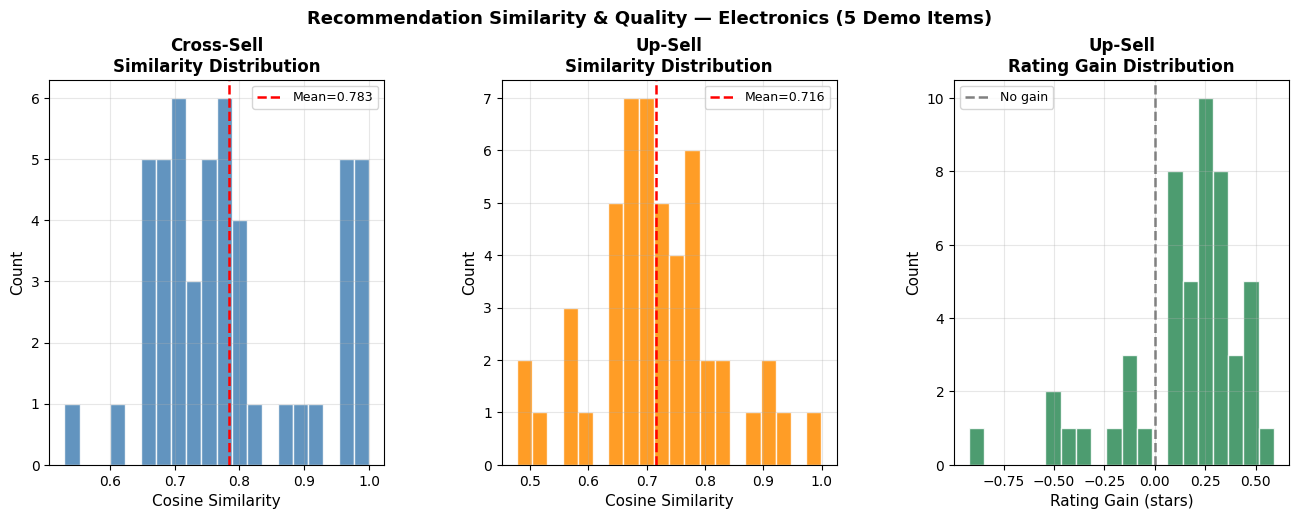

Saved: elec_crossupsell_distributions.png


In [15]:
# Gather scores across all 5 demo items for both modes
cs_sims, us_sims, us_gains = [], [], []

for item_id in demo_items:
    for r in get_recommendations(item_id, mode='cross', k=10, min_sim=0.0):
        cs_sims.append(r['similarity'])
    for r in get_recommendations(item_id, mode='up', k=10, min_sim=0.0):
        us_sims.append(r['similarity'])
        if r['avg_rating'] > 0:
            us_gains.append(r['rating_gain'])

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

def _hist(ax, data, color, title, xlabel, vlines=None):
    ax.hist(data, bins=20, color=color, alpha=0.85, edgecolor='white')
    if vlines:
        for x, lbl, c in vlines:
            ax.axvline(x, color=c, linestyle='--', linewidth=1.8, label=lbl)
        ax.legend(fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.grid(True, alpha=0.3)

if cs_sims:
    _hist(fig.add_subplot(gs[0]), cs_sims, 'steelblue',
          'Cross-Sell\nSimilarity Distribution', 'Cosine Similarity',
          vlines=[(np.mean(cs_sims), f'Mean={np.mean(cs_sims):.3f}', 'red')])

if us_sims:
    _hist(fig.add_subplot(gs[1]), us_sims, 'darkorange',
          'Up-Sell\nSimilarity Distribution', 'Cosine Similarity',
          vlines=[(np.mean(us_sims), f'Mean={np.mean(us_sims):.3f}', 'red')])

if us_gains:
    _hist(fig.add_subplot(gs[2]), us_gains, 'seagreen',
          'Up-Sell\nRating Gain Distribution', 'Rating Gain (stars)',
          vlines=[(0, 'No gain', 'gray')])

fig.suptitle(
    'Recommendation Similarity & Quality — Electronics (5 Demo Items)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('elec_crossupsell_distributions.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: elec_crossupsell_distributions.png")

### Step 15: Coverage & Quality Summary

In [16]:
print("\n" + "=" * 72)
print("  COVERAGE & QUALITY SUMMARY  (200-item random sample)")
print("=" * 72)

all_vocab = [k for k in elec_full_item2idx if k not in ('<PAD>', '<UNK>')]
SAMPLE    = min(200, len(all_vocab))
random.seed(42)
sample_ids = random.sample(all_vocab, SAMPLE)

cs_covered, us_covered   = 0, 0
cs_sim_all, us_sim_all   = [], []

for item_id in sample_ids:
    cr = get_recommendations(item_id, mode='cross', k=5, min_sim=0.30)
    ur = get_recommendations(item_id, mode='up',    k=5, min_sim=0.30)
    if cr:
        cs_covered += 1
        cs_sim_all.extend(r['similarity'] for r in cr)
    if ur:
        us_covered += 1
        us_sim_all.extend(r['similarity'] for r in ur)

print(f"\n  Evaluated on {SAMPLE} randomly sampled vocabulary items")
print()
print("  Cross-Sell  (sim >= 0.30):")
print(f"    Items with >=1 recommendation : {cs_covered}/{SAMPLE} ({cs_covered/SAMPLE*100:.1f}%) {cs_covered/SAMPLE*100:.1f}%) ")
if cs_sim_all:
    print(f"    Mean similarity              : {np.mean(cs_sim_all):.4f}")
    strong = sum(1 for s in cs_sim_all if s >= 0.70)
    print(f"    Strong hits (sim >= 0.70)    : {strong} results")
print()
print("  Up-Sell     (sim >= 0.30):")
print(f"    Items with >=1 recommendation : {us_covered}/{SAMPLE} ({us_covered/SAMPLE*100:.1f}%) ")
if us_sim_all:
    print(f"    Mean similarity              : {np.mean(us_sim_all):.4f}")
    strong = sum(1 for s in us_sim_all if s >= 0.70)
    print(f"    Strong hits (sim >= 0.70)    : {strong} results")
print()
print("  Interpretation guide:")
print("    Coverage >= 70%   → retrieval is reliable across the catalogue")
print("    Mean sim  >= 0.50 → strong semantic alignment in embedding space")
print("    Strong    >= 50%  → most recommendations are high-confidence")
print("=" * 72)
print("  DEMONSTRATION COMPLETE")
print("=" * 72)


  COVERAGE & QUALITY SUMMARY  (200-item random sample)

  Evaluated on 200 randomly sampled vocabulary items

  Cross-Sell  (sim >= 0.30):
    Items with >=1 recommendation : 200/200 (100.0%) 100.0%) 
    Mean similarity              : 0.8300
    Strong hits (sim >= 0.70)    : 919 results

  Up-Sell     (sim >= 0.30):
    Items with >=1 recommendation : 199/200 (99.5%) 
    Mean similarity              : 0.7962
    Strong hits (sim >= 0.70)    : 780 results

  Interpretation guide:
    Coverage >= 70%   → retrieval is reliable across the catalogue
    Mean sim  >= 0.50 → strong semantic alignment in embedding space
    Strong    >= 50%  → most recommendations are high-confidence
  DEMONSTRATION COMPLETE
